In [1]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

  Using cached matplotlib-3.9.3.tar.gz (36.1 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... error
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [231 lines of output]
      + meson setup /private/var/folders/kx/fvv6fqkn6bx9d3pt74j15g9r0000gn/T/pip-install-115zlper/matplotlib_fd0193b695b849bab630fed0a34ddd17 /private/var/folders/kx/fvv6fqkn6bx9d3pt74j15g9r0000gn/T/pip-install-115zlper/matplotlib_fd0193b695b849bab630fed0a34ddd17/.mesonpy-oixkde08 -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=/private/var/folders/kx/fvv6fqkn6bx9d3pt74j15g9r0000gn/T/pip-install-115zlper/matplotlib_fd0193b695b849bab630fed0a34ddd17/.mesonpy-oixkde08/meson-python-native-file.ini
      The Meson build system
      Version: 1.12.1
      Source dir: /private/var/folders/kx/fvv6fqk

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

%matplotlib inline 

import warnings
warnings.filterwarnings('ignore')

In [ ]:
'''
السيناريو: شركة اتصالات تواجه مشكلة انتقال العملاء للمنافسين، وتريد تحديد الفئات الأكثر عرضة للمغادرة.

الهدف: التنبؤ بالعملاء الذين سيبقون مع الشركة لتقليل نسبة التسرب
(Customer Churn)، لأن الحفاظ على العملاء أقل تكلفة من جلب عملاء جدد.

البيانات: مجموعة بيانات تحتوي على تفاصيل العملاء والشخصية والخدمات المشتركين بها واستخدامهم المعتاد.
'''

In [3]:
#1 Load Data from URL
# churn_df = pd.read_csv("ChurnData.csv")
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"
churn_df = pd.read_csv(url)

churn_df

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1.0,23.0,0.0,1.0,0.0,17.35,...,0.0,0.0,0.0,1.0,0.0,2.854,3.199,4.419,3.0,0.0
196,34.0,23.0,3.0,24.0,1.0,7.0,0.0,1.0,0.0,6.00,...,0.0,0.0,1.0,1.0,0.0,1.792,3.332,3.178,3.0,0.0
197,6.0,32.0,10.0,47.0,1.0,10.0,0.0,1.0,0.0,3.85,...,0.0,0.0,1.0,1.0,0.0,1.348,3.168,3.850,3.0,0.0
198,24.0,30.0,0.0,25.0,4.0,5.0,0.0,1.0,1.0,8.70,...,1.0,1.0,1.0,1.0,1.0,2.163,3.866,3.219,4.0,1.0


In [15]:
#Data Preprocessing معالجة البيانات واختيار المتغيرات
#اختيار الأعمدة المهمة للتنبؤ1 
churn_df = churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'churn']]
#2 تحويل عمود الهدف churn إلى أرقام صحيحة
churn_df['churn'] = churn_df['churn'].astype('int')
churn_df

,tenure,age,address,income,ed,employ,equip,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,0
...,...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1.0,23.0,0.0,0
196,34.0,23.0,3.0,24.0,1.0,7.0,0.0,0
197,6.0,32.0,10.0,47.0,1.0,10.0,0.0,0
198,24.0,30.0,0.0,25.0,4.0,5.0,0.0,1


In [ ]:
'''
For modeling the input fields X and the target field y need to be fixed. 
Since that the target to be predicted is 'churn', the data under this field will be 
stored under the variable 'y'. We may use any combination or all of the remaining fields 
as the input. Store these values in the variable 'X'
'''

In [5]:
# فصل الممميزات المستقله X 
X = np.asarray(churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']])
X[0:5]  #print the first 5 values

array([[ 11.,  33.,   7., 136.,   5.,   5.,   0.],
       [ 33.,  33.,  12.,  33.,   2.,   0.,   0.],
       [ 23.,  30.,   9.,  30.,   1.,   2.,   0.],
       [ 38.,  35.,   5.,  76.,   2.,  10.,   1.],
       [  7.,  35.,  14.,  80.,   2.,  15.,   0.]])

In [6]:
#فصل الهدف y
y = np.asarray(churn_df['churn'])
y[0:5] #print the first 5 values

array([1, 1, 0, 0, 0])

In [ ]:
#normalize the dataset in order to have all the features at the same scale. 
#This helps the model learn faster and improves the model performance. 

In [16]:
# موازنة مقاييس البيانات باستخدام StandardScaler لتسريع وتسهيل تدريب النموذج
#تطبيق StandardScaler يمنع تحيز النموذج للأرقام الكبيرة، ويضمن وصول النموذج لأفضل دقة ممكنة بكتلة حسابية أسرع وأكثر استقراراً.
X_norm = StandardScaler().fit(X).transform(X)
X_norm[0:5]


array([[-1.13518441, -0.62595491, -0.4588971 ,  0.4751423 ,  1.6961288 ,
        -0.58477841, -0.85972695],
       [-0.11604313, -0.62595491,  0.03454064, -0.32886061, -0.6433592 ,
        -1.14437497, -0.85972695],
       [-0.57928917, -0.85594447, -0.261522  , -0.35227817, -1.42318853,
        -0.92053635, -0.85972695],
       [ 0.11557989, -0.47262854, -0.65627219,  0.00679109, -0.6433592 ,
        -0.02518185,  1.16316   ],
       [-1.32048283, -0.47262854,  0.23191574,  0.03801451, -0.6433592 ,
         0.53441472, -0.85972695]])

In [8]:
#Splitting the data into training and testing sets:
X_train, X_test, y_train, y_test = train_test_split( X_norm, y, test_size=0.2, random_state=4)

In [9]:
#Logistic Regression Classifier modeling
LR = LogisticRegression().fit(X_train,y_train) #fitting is training 

In [10]:
#predecting the churn parameter for the test data set
yhat = LR.predict(X_test) #التنبؤ بالفئات (0 أو 1)
yhat[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [ ]:
'''
To understand this prediction, we can also have a look at the prediction 
probability of data point of the test data set. Use the function predict_proba , 
we can get the probability of each class. The first column is the probability 
of the record belonging to class 0, and second column that of class 1.
Note that the class prediction system uses the threshold for class prediction as 0.5.
This means that the class predicted is the one which is most likely.
'''

In [11]:
yhat_prob = LR.predict_proba(X_test) #حساب احتمالية كل فئة
yhat_prob[:10]

array([[0.74643946, 0.25356054],
       [0.92667894, 0.07332106],
       [0.83442627, 0.16557373],
       [0.94600618, 0.05399382],
       [0.84325532, 0.15674468],
       [0.71448367, 0.28551633],
       [0.77076426, 0.22923574],
       [0.90955642, 0.09044358],
       [0.26152115, 0.73847885],
       [0.94900731, 0.05099269]])

In [ ]:
'''
Since the purpose here is to predict the 1 class more acccurately,
you can also examine what role each input feature has to play in 
the prediction of the 1 class. Consider the code below.
'''

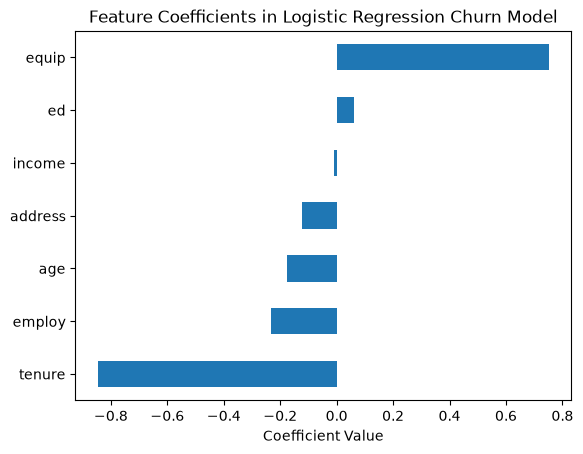

In [12]:
# رسم بياني لمعاملات المتغيرات لمعرفة تأثير كل ميزة
coefficients = pd.Series(LR.coef_[0], index=churn_df.columns[:-1])
coefficients.sort_values().plot(kind='barh')
plt.title("Feature Coefficients in Logistic Regression Churn Model")
plt.xlabel("Coefficient Value")
plt.show()

In [17]:
#log loss قياس نسبة الخطأ في احتمالات التنبؤ
log_loss(y_test, yhat_prob)

0.6257718410257235